# Modélisation — Climate Risk & Health

Métrique cible : **0.6 × F1 + 0.4 × ROC-AUC**  
Seuil de décision : **fixé à 0.5** (règle du challenge — ne pas optimiser)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import xgboost as xgb
import shap

DATA = Path('../data')
SEED = 42

def zindi_score(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)
    return 0.6 * f1 + 0.4 * auc, f1, auc

print('Librairies chargées.')

Librairies chargées.


## 1. Chargement des données prétraitées

In [2]:
# Si le notebook 02 n'a pas encore tourné, on recrée les features ici
if (DATA / 'X_train.parquet').exists():
    X_train   = pd.read_parquet(DATA / 'X_train.parquet')
    y_train   = pd.read_parquet(DATA / 'y_train.parquet').squeeze()
    X_test    = pd.read_parquet(DATA / 'X_test.parquet')
    test_ids  = pd.read_parquet(DATA / 'test_ids.parquet').squeeze()
    print('Données chargées depuis parquet.')
else:
    print('Lancer d abord le notebook 02_feature_engineering.ipynb')

# Récupérer la colonne location pour le GroupKFold
train_raw = pd.read_csv(DATA / 'Train.csv')
groups = train_raw['location'].values  # groupes pour la CV

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'Nb groupes (locations) : {len(np.unique(groups))}')

Données chargées depuis parquet.
X_train : (3146, 59)
X_test  : (1030, 59)
Nb groupes (locations) : 39


## 2. Stratégie de validation croisée

**GroupKFold par location** : simule la généralisation vers des zones géographiques non vues (comme le test set réel).  
**StratifiedKFold** : fallback pour vérifier la stabilité du score.

In [3]:
N_SPLITS = 5
cv_group = GroupKFold(n_splits=N_SPLITS)
cv_strat = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

print(f'GroupKFold : {N_SPLITS} folds par location')
print('Distribution des groupes dans chaque fold :')
for fold, (train_idx, val_idx) in enumerate(cv_group.split(X_train, y_train, groups)):
    tr_grps = set(groups[train_idx])
    va_grps = set(groups[val_idx])
    print(f'  Fold {fold+1}: train={len(tr_grps)} locs, val={len(va_grps)} locs | val_size={len(val_idx)}')

GroupKFold : 5 folds par location
Distribution des groupes dans chaque fold :
  Fold 1: train=32 locs, val=7 locs | val_size=638
  Fold 2: train=32 locs, val=7 locs | val_size=636
  Fold 3: train=31 locs, val=8 locs | val_size=626
  Fold 4: train=30 locs, val=9 locs | val_size=622
  Fold 5: train=31 locs, val=8 locs | val_size=624


## 3. Baseline — LightGBM

In [4]:
LGBM_PARAMS = {
    'objective': 'binary',
    'metric': 'auc',
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'class_weight': 'balanced',
    'random_state': SEED,
    'n_jobs': -1,
    'verbose': -1,
}

# Encoder zone/gender en entier (LabelEncoding) — évite les problèmes de catégories entre folds
CAT_COLS = ['zone', 'gender']
encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))
    encoders[col] = le

print('Encodage label effectué pour :', CAT_COLS)
print('Aperçu X_train dtypes :', X_train.dtypes.value_counts().to_dict())

Encodage label effectué pour : ['zone', 'gender']
Aperçu X_train dtypes : {dtype('float64'): 37, dtype('int64'): 19, dtype('int32'): 3}


In [5]:
def run_cv(X, y, groups, params, cv, model_name='LightGBM', use_groups=True):
    oof_probs   = np.zeros(len(y))
    fold_scores = []
    models      = []

    splits = cv.split(X, y, groups) if use_groups else cv.split(X, y)

    for fold, (tr_idx, va_idx) in enumerate(splits):
        X_tr, X_va = X.iloc[tr_idx].copy(), X.iloc[va_idx].copy()
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)],
        )

        probs = model.predict_proba(X_va)[:, 1]
        oof_probs[va_idx] = probs
        score, f1, auc = zindi_score(y_va, probs)
        fold_scores.append((score, f1, auc))
        models.append(model)
        print(f'  Fold {fold+1}: score={score:.4f}  F1={f1:.4f}  AUC={auc:.4f}  trees={model.best_iteration_}')

    oof_score, oof_f1, oof_auc = zindi_score(y, oof_probs)
    print(f'\n[{model_name}] OOF score={oof_score:.4f}  F1={oof_f1:.4f}  AUC={oof_auc:.4f}')
    return oof_probs, models, fold_scores

print('Lancement CV GroupKFold LightGBM...')
oof_lgbm_group, models_lgbm_group, scores_lgbm_group = run_cv(
    X_train, y_train, groups, LGBM_PARAMS, cv_group, 'LGBM-GroupKFold', use_groups=True
)

Lancement CV GroupKFold LightGBM...


  Fold 1: score=0.8044  F1=0.7899  AUC=0.8262  trees=83


  Fold 2: score=0.8016  F1=0.7836  AUC=0.8287  trees=55


  Fold 3: score=0.7771  F1=0.7531  AUC=0.8130  trees=20


  Fold 4: score=0.7921  F1=0.7767  AUC=0.8152  trees=7


  Fold 5: score=0.7872  F1=0.7802  AUC=0.7976  trees=68

[LGBM-GroupKFold] OOF score=0.7863  F1=0.7771  AUC=0.8000


In [6]:
print('\nLancement CV StratifiedKFold LightGBM (comparaison)...')
oof_lgbm_strat, models_lgbm_strat, scores_lgbm_strat = run_cv(
    X_train, y_train, groups, LGBM_PARAMS, cv_strat, 'LGBM-StratKFold', use_groups=False
)

print('\n--- Comparaison ---')
s_g, f1_g, auc_g = zindi_score(y_train, oof_lgbm_group)
s_s, f1_s, auc_s = zindi_score(y_train, oof_lgbm_strat)
print(f'GroupKFold  : score={s_g:.4f}  F1={f1_g:.4f}  AUC={auc_g:.4f}')
print(f'StratKFold  : score={s_s:.4f}  F1={f1_s:.4f}  AUC={auc_s:.4f}')


Lancement CV StratifiedKFold LightGBM (comparaison)...


  Fold 1: score=0.8135  F1=0.8051  AUC=0.8262  trees=9


  Fold 2: score=0.8075  F1=0.7963  AUC=0.8242  trees=22


  Fold 3: score=0.7918  F1=0.7699  AUC=0.8248  trees=12


  Fold 4: score=0.7636  F1=0.7439  AUC=0.7932  trees=21


  Fold 5: score=0.7661  F1=0.7490  AUC=0.7918  trees=15

[LGBM-StratKFold] OOF score=0.7858  F1=0.7734  AUC=0.8044

--- Comparaison ---
GroupKFold  : score=0.7863  F1=0.7771  AUC=0.8000
StratKFold  : score=0.7858  F1=0.7734  AUC=0.8044


## 4. Analyse des erreurs OOF

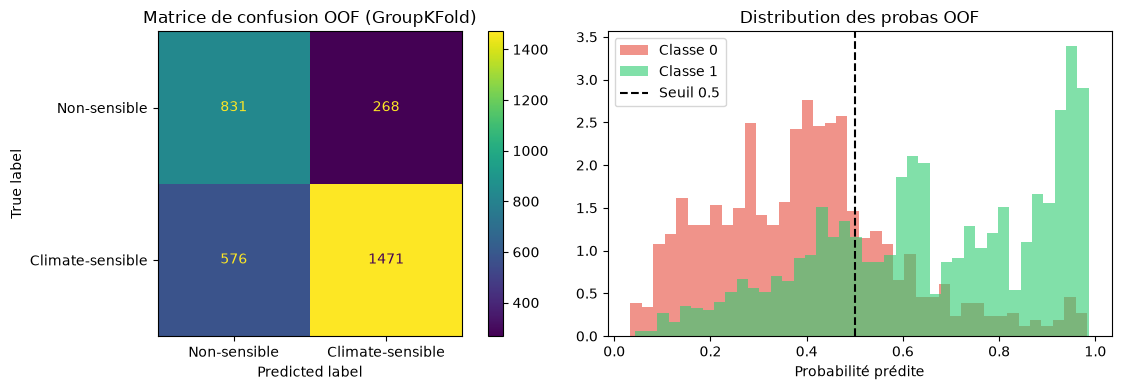

In [7]:
# Matrice de confusion OOF
oof_pred = (oof_lgbm_group >= 0.5).astype(int)
cm = confusion_matrix(y_train, oof_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(cm, display_labels=['Non-sensible', 'Climate-sensible']).plot(ax=axes[0])
axes[0].set_title('Matrice de confusion OOF (GroupKFold)')

# Distribution des probabilités OOF
axes[1].hist(oof_lgbm_group[y_train==0], bins=40, alpha=0.6, color='#e74c3c', label='Classe 0', density=True)
axes[1].hist(oof_lgbm_group[y_train==1], bins=40, alpha=0.6, color='#2ecc71', label='Classe 1', density=True)
axes[1].axvline(0.5, color='black', linestyle='--', label='Seuil 0.5')
axes[1].set_xlabel('Probabilité prédite')
axes[1].set_title('Distribution des probas OOF')
axes[1].legend()
plt.tight_layout()
plt.savefig('../notes/fig_oof_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Importance des features (SHAP)

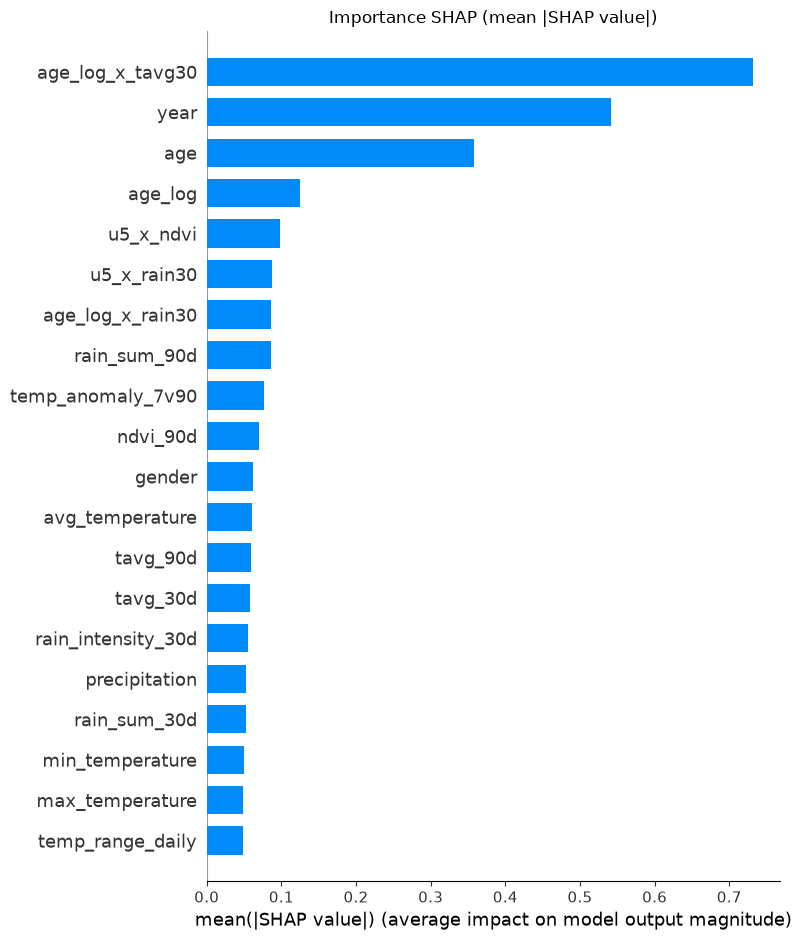

In [8]:
# SHAP sur le premier modèle de la CV group
explainer = shap.TreeExplainer(models_lgbm_group[0])

# Prendre un échantillon pour la vitesse
sample_idx = np.random.RandomState(SEED).choice(len(X_train), size=min(500, len(X_train)), replace=False)
X_sample = X_train.iloc[sample_idx].copy()
for col in X_sample.select_dtypes(include='category').columns:
    X_sample[col] = X_sample[col].cat.codes

shap_values = explainer.shap_values(X_sample)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_sample, plot_type='bar', show=False, max_display=20)
plt.title('Importance SHAP (mean |SHAP value|)')
plt.tight_layout()
plt.savefig('../notes/fig_shap_importance.png', dpi=120, bbox_inches='tight')
plt.show()

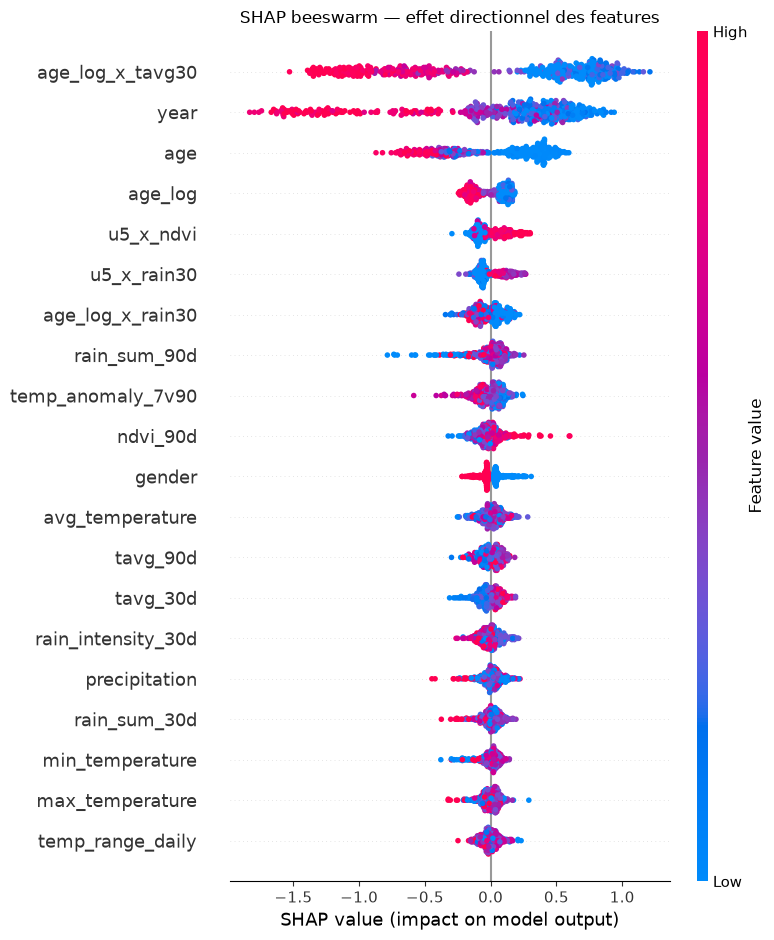

In [9]:
plt.figure(figsize=(10, 10))
shap.summary_plot(shap_vals, X_sample, show=False, max_display=20)
plt.title('SHAP beeswarm — effet directionnel des features')
plt.tight_layout()
plt.savefig('../notes/fig_shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Prédictions test et soumission

In [10]:
# Moyenne des prédictions de tous les folds (ensemble naturel de la CV)
test_probs = np.zeros(len(X_test))
cat_cols_local = X_test.select_dtypes(include='category').columns.tolist()

for model in models_lgbm_group:
    test_probs += model.predict_proba(X_test)[:, 1]
test_probs /= len(models_lgbm_group)

print(f'Distribution des probas test :')
print(f'  Mean  : {test_probs.mean():.4f}')
print(f'  Std   : {test_probs.std():.4f}')
print(f'  Min   : {test_probs.min():.4f}')
print(f'  Max   : {test_probs.max():.4f}')
print(f'  Pred 1 (>=0.5) : {(test_probs >= 0.5).mean():.1%}')

Distribution des probas test :
  Mean  : 0.5738
  Std   : 0.2225
  Min   : 0.1602
  Max   : 0.8774
  Pred 1 (>=0.5) : 56.5%


In [11]:
# Création du fichier de soumission
submission = pd.DataFrame({
    'ID': test_ids,
    'TargetF1':   (test_probs >= 0.5).astype(int),  # seuil fixé à 0.5
    'TargetRAUC': test_probs
})

# Vérification du format
sample = pd.read_csv(DATA / 'SampleSubmission.csv')
assert list(submission.columns) == list(sample.columns), 'ERREUR : colonnes incorrectes'
assert len(submission) == len(sample), f'ERREUR : {len(submission)} lignes vs {len(sample)} attendues'
assert set(submission.ID) == set(sample.ID), 'ERREUR : IDs incorrects'

# Aligner l'ordre des IDs sur le sample submission
submission = submission.set_index('ID').loc[sample.ID].reset_index()

# Vérification finale
print(f'✓ Format correct : {submission.shape}')
print(f'✓ TargetF1  : {submission.TargetF1.value_counts().to_dict()}')
print(f'✓ TargetRAUC range : [{submission.TargetRAUC.min():.4f}, {submission.TargetRAUC.max():.4f}]')
submission.head()

✓ Format correct : (1030, 3)
✓ TargetF1  : {1: 582, 0: 448}
✓ TargetRAUC range : [0.1602, 0.8774]


,ID,TargetF1,TargetRAUC
0,ID_E760D84B,0,0.334339
1,ID_6EDEA907,1,0.622319
2,ID_B9FFC8D8,0,0.430464
3,ID_74C6C94E,0,0.403708
4,ID_0E02825D,1,0.633566


In [12]:
# Nommer la soumission avec le score OOF pour traçabilité
oof_score_str = f'{s_g:.4f}'.replace('.', '')
submission_path = DATA / f'submission_lgbm_group_{oof_score_str}.csv'
submission.to_csv(submission_path, index=False)
print(f'Soumission sauvegardée : {submission_path}')

Soumission sauvegardée : ../data/submission_lgbm_group_07863.csv


## 7. Log des expériences

In [13]:
import csv, datetime

log_path = Path('../notes/experiments.csv')
log_row = {
    'date': datetime.datetime.now().strftime('%Y-%m-%d %H:%M'),
    'model': 'LightGBM',
    'cv_strategy': 'GroupKFold-location-5fold',
    'cv_score': f'{s_g:.4f}',
    'cv_f1': f'{f1_g:.4f}',
    'cv_auc': f'{auc_g:.4f}',
    'lb_public': '',
    'notes': 'Baseline LightGBM, features v1, class_weight=balanced, threshold=0.5'
}

file_exists = log_path.exists()
with open(log_path, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=log_row.keys())
    if not file_exists:
        writer.writeheader()
    writer.writerow(log_row)

print(f'Log mis à jour : {log_path}')
print(pd.read_csv(log_path).to_string())

Log mis à jour : ../notes/experiments.csv
               date     model                cv_strategy  cv_score   cv_f1  cv_auc  lb_public                                                                 notes
0  2026-09-10 11:08  LightGBM  GroupKFold-location-5fold    0.7863  0.7771     0.8        NaN  Baseline LightGBM, features v1, class_weight=balanced, threshold=0.5
